# RETINEXPLAIN --Baseline model ( EfficientNet-B0 )
**Author:** Ashik Kannampilly Janardhanan | MSc Artificial Intelligence and Machine Learning
**Student ID:** 25032615 | University of Limerick
**Supervisors:** Dr. Allan de Lima and Dr. Douglas Mota Dias

---
EfficientNet-B0 is trained end-to-end as a black-box baseline. The full backbone is fine-tuned directly on disease labels with no concept bottleneck and no interpretability.

The performance gap between this baseline and RETINEXPLAIN represents the accuracy cost of producing human-readable explanations.

### Cell 1 -- Libraries and Configuration

#### Imports all required libraries, defines dataset and output directory paths, selects the compute device and initialises the disease class name list used throughout this notebook.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import ( classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score )

SEED = 123
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)
random.seed(SEED)

DATASET_PATH  = '/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'
IMAGES_PATH   = os.path.join(DATASET_PATH, 'preprocessed_images')
OUTPUT_PATH   = '/kaggle/working'
device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
disease_names = ['Normal', 'Diabetic Retinopathy', 'Glaucoma',
                 'Cataract', 'AMD', 'Hypertension', 'Myopia']

print("Libraries ready.")

Libraries ready.


### Cell 2 -- Dataset Loading and Patient-Level Split

#### Loads the ODIR-5K CSV, parses and filters labels to the seven primary disease classes, and performs a stratified patient-level 70/15/15 train, validation and test split to prevent data leakage between splits.

In [2]:
df = pd.read_csv(os.path.join(DATASET_PATH, 'full_df.csv'))

label_map    = {'N': 'Normal', 'D': 'Diabetic Retinopathy', 'G': 'Glaucoma',
                'C': 'Cataract', 'A': 'AMD', 'H': 'Hypertension', 'M': 'Myopia'}
label_to_idx = {'N': 0, 'D': 1, 'G': 2, 'C': 3, 'A': 4, 'H': 5, 'M': 6}

def parse_label(label_str):
    return str(label_str).replace('[', '').replace(']', '').replace("'", '').strip()

df['label_parsed'] = df['labels'].apply(parse_label)
df_clean = df[df['label_parsed'].isin(label_to_idx.keys())].copy()
df_clean['label']  = df_clean['label_parsed']
df_clean['label_idx'] = df_clean['label'].map(label_to_idx)

patient_labels = df_clean.groupby('ID')['label'].first().reset_index()
train_ids, temp_ids = train_test_split( patient_labels['ID'], test_size=0.30, random_state=42, stratify=patient_labels['label'])
temp_labels = patient_labels[patient_labels['ID'].isin(temp_ids)]
val_ids, test_ids = train_test_split( temp_labels['ID'], test_size=0.50, random_state=42, stratify=temp_labels['label'])

df_train = df_clean[df_clean['ID'].isin(train_ids)].copy().reset_index(drop=True)
df_val   = df_clean[df_clean['ID'].isin(val_ids)].copy().reset_index(drop=True)
df_test  = df_clean[df_clean['ID'].isin(test_ids)].copy().reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 3973 | Val: 851 | Test: 860


### Cell 3 -- Dataset and DataLoader

#### Defines the DiseaseDataset class that loads retinal images by filename, applies training augmentation and validation normalisation transforms, and creates DataLoaders for all three splits.

In [3]:
class DiseaseDataset(Dataset):
    def __init__(self, dataframe, images_path, transform=None):
        self.images_path = images_path
        self.transform   = transform  # store as instance attribute
        self.samples  = []
        for _, row in dataframe.iterrows():
            img_path = os.path.join(images_path, row['filename'])
            if os.path.exists(img_path):
                self.samples.append((img_path, int(row['label_idx'])))
        print(f"  Dataset ready: {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Creating datasets...")
train_ds = DiseaseDataset(df_train, IMAGES_PATH, train_transform)
val_ds = DiseaseDataset(df_val,   IMAGES_PATH, val_transform)
test_ds  = DiseaseDataset(df_test,  IMAGES_PATH, val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Creating datasets...
  Dataset ready: 3973 images
  Dataset ready: 851 images
  Dataset ready: 860 images
Train batches: 125 | Val batches: 27


### Cell 4 -- EfficientNet Baseline Model

#### Defines the end-to-end EfficientNet-B0 baseline with all backbone weights trainable and the final classifier replaced with a seven-class output layer. Unlike RETINEXPLAIN's frozen backbone, the full network is fine-tuned directly on disease labels.

In [4]:
class EfficientNetBaseline(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

baseline_model = EfficientNetBaseline(num_classes=7).to(device)
total = sum(p.numel() for p in baseline_model.parameters())
trainable = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)

print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")
print(f"Backbone             : fully fine-tuned")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 215MB/s]


Total parameters     : 4,016,515
Trainable parameters : 4,016,515
Backbone             : fully fine-tuned


### Cell 5 -- EfficientNet Training

#### Trains the EfficientNet baseline end-to-end using CrossEntropyLoss with inverse-frequency class weights, Adam optimiser and early stopping monitored on validation loss. The best model checkpoint is restored after training completes.

In [5]:
label_counts  = np.array([ (df_train['label'] == lbl).sum() for lbl in ['N','D','G','C','A','H','M'] ])
class_weights = torch.tensor( 1.0 / (label_counts / label_counts.sum()), dtype=torch.float32 ).to(device)
class_weights = class_weights / class_weights.sum() * len(class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(baseline_model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

EPOCHS   = 50
PATIENCE = 7
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
best_model_state = None

print(f"Training for up to {EPOCHS} epochs...")
print()

for epoch in range(EPOCHS):
    baseline_model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(baseline_model(images), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    baseline_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            val_loss += criterion(baseline_model(images), labels).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}", end='')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in baseline_model.state_dict().items()}
        patience_counter = 0
        print(" <-- Best")
    else:
        patience_counter += 1
        print()
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

baseline_model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")

Training for up to 50 epochs...

Epoch   1/50 | Train: 1.4032 | Val: 1.3699 <-- Best
Epoch   2/50 | Train: 0.9701 | Val: 1.1491 <-- Best
Epoch   3/50 | Train: 0.7764 | Val: 1.1517
Epoch   4/50 | Train: 0.6820 | Val: 1.0885 <-- Best
Epoch   5/50 | Train: 0.5890 | Val: 1.0903
Epoch   6/50 | Train: 0.4848 | Val: 1.1122
Epoch   7/50 | Train: 0.4258 | Val: 1.1034
Epoch   8/50 | Train: 0.3721 | Val: 1.0685 <-- Best
Epoch   9/50 | Train: 0.3707 | Val: 1.0502 <-- Best
Epoch  10/50 | Train: 0.3275 | Val: 1.1609
Epoch  11/50 | Train: 0.2979 | Val: 1.0931
Epoch  12/50 | Train: 0.3055 | Val: 1.2129
Epoch  13/50 | Train: 0.2738 | Val: 1.1903
Epoch  14/50 | Train: 0.2452 | Val: 1.2284
Epoch  15/50 | Train: 0.2250 | Val: 1.2857
Epoch  16/50 | Train: 0.2106 | Val: 1.2247
Early stopping at epoch 16

Best validation loss: 1.0502


### Cell 6 -- Training Curves

#### Plots training and validation loss across epochs to visualise convergence and confirm that early stopping triggered at the right point.

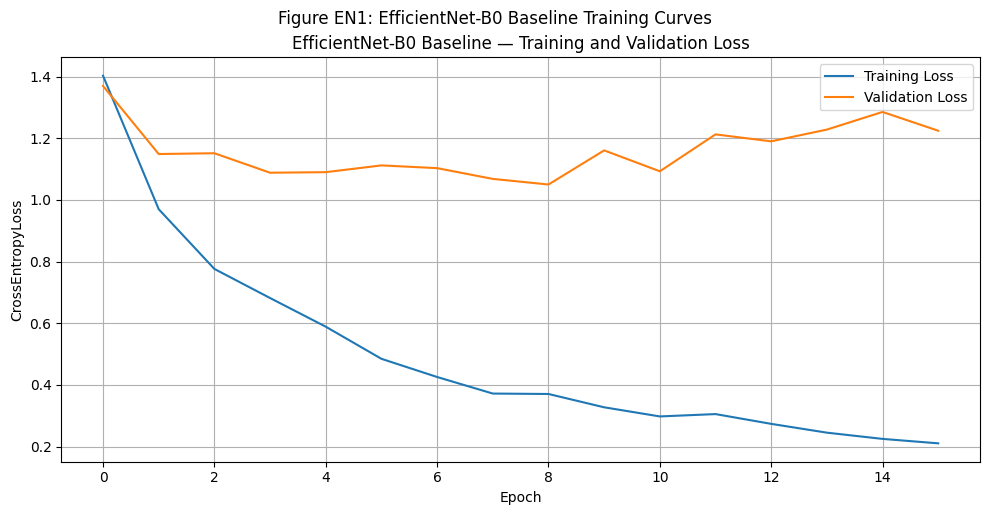

Figure saved: figEN1_curves.png


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropyLoss')
plt.title('EfficientNet-B0 Baseline — Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.suptitle('Figure EN1: EfficientNet-B0 Baseline Training Curves', fontsize=12, y=1.02)
plt.savefig(os.path.join(OUTPUT_PATH, 'figEN1_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figEN1_curves.png")

### Cell 7 -- Test Set Evaluation

#### Evaluates the trained EfficientNet baseline on the held-out test set and reports accuracy, Macro F1 and the full per-class classification report.

In [7]:
baseline_model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = baseline_model(images.to(device))
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

test_accuracy = accuracy_score(all_true, all_preds)
macro_f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)

print("=" * 60)
print("EfficientNet-B0 End-to-End Baseline — Test Set Results")
print("=" * 60)
print()
print(f"Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Macro F1 : {macro_f1:.4f}")
print()
print(classification_report(all_true, all_preds, target_names=disease_names, zero_division=0))

EfficientNet-B0 End-to-End Baseline — Test Set Results

Accuracy : 0.6012 (60.12%)
Macro F1 : 0.5829

                      precision    recall  f1-score   support

              Normal       0.74      0.62      0.67       435
Diabetic Retinopathy       0.61      0.50      0.55       250
            Glaucoma       0.37      0.55      0.44        42
            Cataract       0.86      0.82      0.84        44
                 AMD       0.59      0.72      0.65        36
        Hypertension       0.05      0.28      0.09        18
              Myopia       0.77      0.94      0.85        35

            accuracy                           0.60       860
           macro avg       0.57      0.63      0.58       860
        weighted avg       0.67      0.60      0.63       860



### Cell 8 -- Confusion Matrix

#### Plots count and row-normalised confusion matrices for the EfficientNet baseline on the test set, showing which disease classes are correctly classified and which are confused with each other.

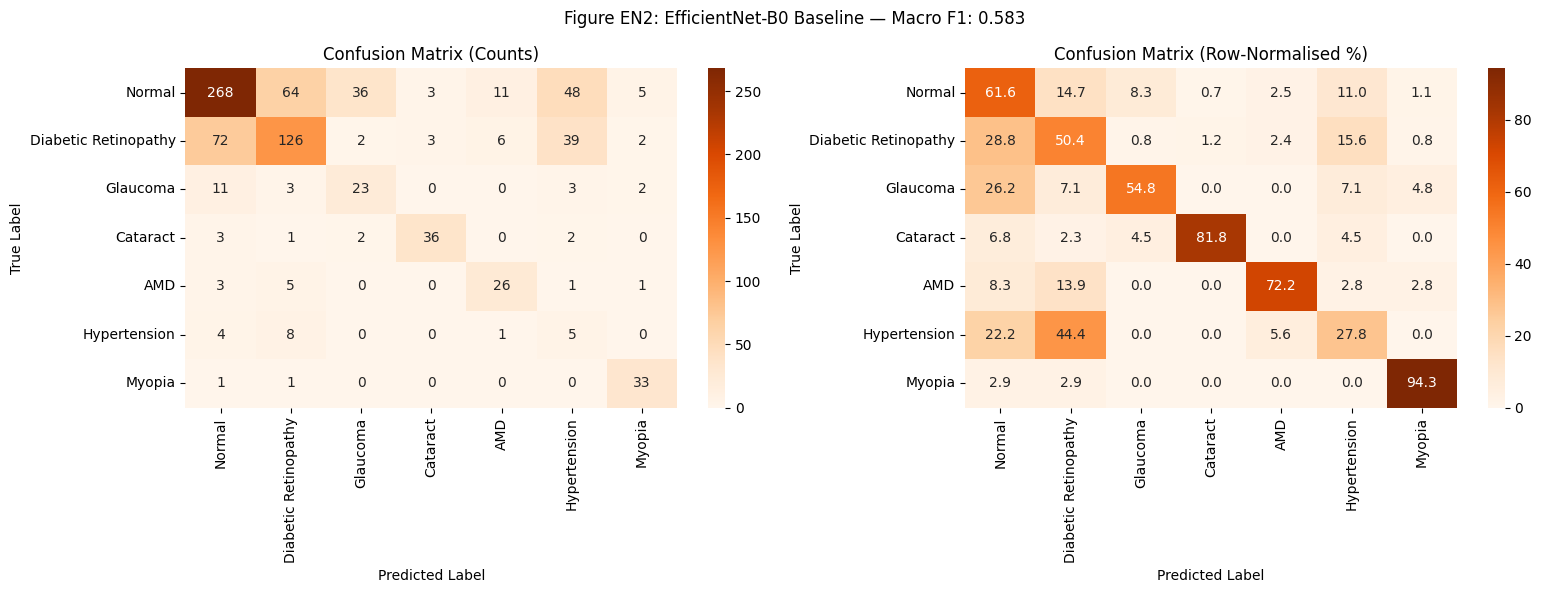

Figure saved: figEN2_confusion_matrix.png


In [8]:
cm = confusion_matrix(all_true, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=disease_names, yticklabels=disease_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', xticklabels=disease_names, yticklabels=disease_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Row-Normalised %)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle(f'Figure EN2: EfficientNet-B0 Baseline — Macro F1: {macro_f1:.3f}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'figEN2_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figEN2_confusion_matrix.png")

### Cell 9 -- Per-Class Performance

#### Bar chart and exact values table showing per-class precision, recall and F1 for the EfficientNet baseline, with the overall Macro F1 shown as a reference line.

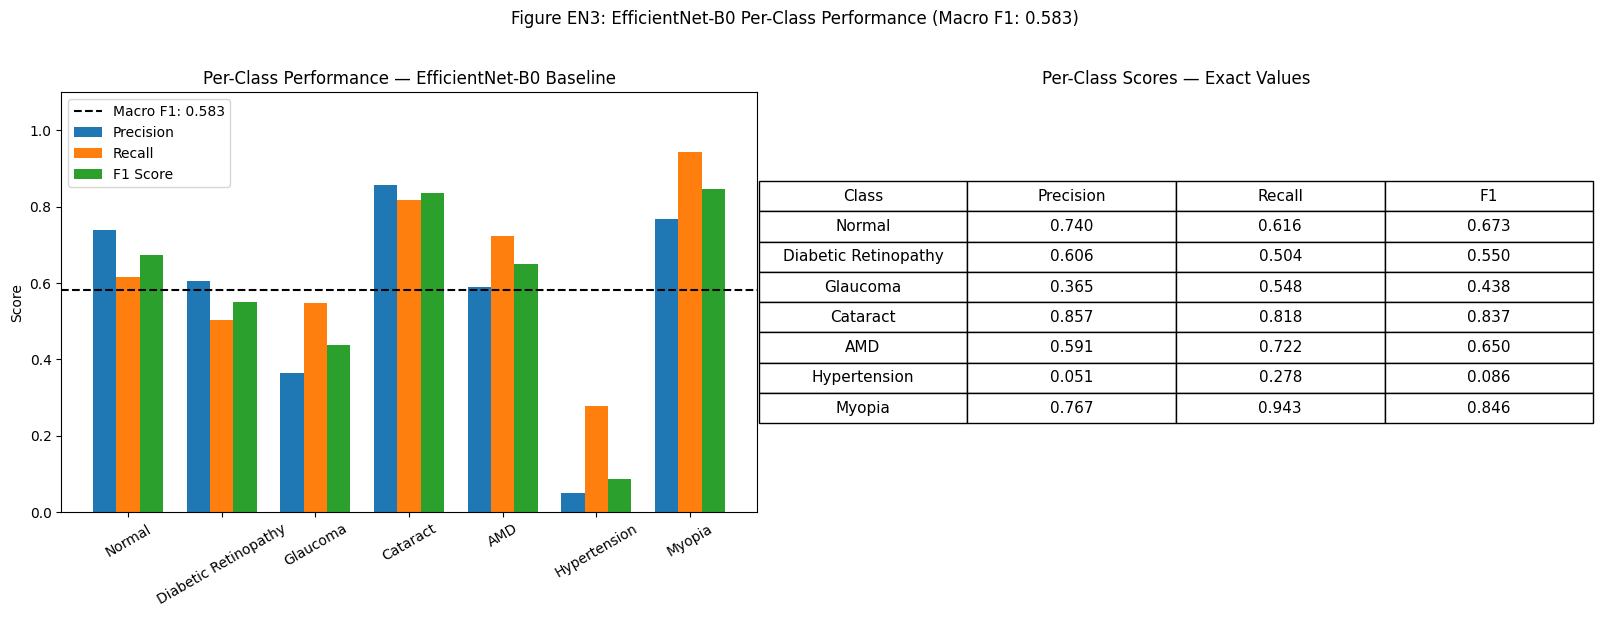

Figure saved: figEN3_per_class.png


In [9]:
precisions = precision_score(all_true, all_preds, average=None, zero_division=0, labels=list(range(7)))
recalls = recall_score( all_true, all_preds, average=None, zero_division=0, labels=list(range(7)))
f1s = f1_score( all_true, all_preds, average=None, zero_division=0, labels=list(range(7)))

x = np.arange(len(disease_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x - width, precisions, width, label='Precision')
axes[0].bar(x, recalls, width, label='Recall')
axes[0].bar(x + width, f1s, width, label='F1 Score')
axes[0].axhline(y=macro_f1, color='black', linestyle='--', label=f'Macro F1: {macro_f1:.3f}')
axes[0].set_title('Per-Class Performance — EfficientNet-B0 Baseline')
axes[0].set_xticks(x)
axes[0].set_xticklabels(disease_names, rotation=30)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

table_data = []
for i, name in enumerate(disease_names):
    table_data.append([name, f'{precisions[i]:.3f}', f'{recalls[i]:.3f}', f'{f1s[i]:.3f}'])

table = axes[1].table( cellText=table_data, colLabels=['Class', 'Precision', 'Recall', 'F1'], loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)
axes[1].axis('off')
axes[1].set_title('Per-Class Scores — Exact Values')

plt.suptitle(f'Figure EN3: EfficientNet-B0 Per-Class Performance (Macro F1: {macro_f1:.3f})', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'figEN3_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figEN3_per_class.png")

### Cell 10 -- Summary

#### Final summary of the EfficientNet-B0 baseline results including architecture description, test set accuracy and Macro F1, and per-class F1 scores.

In [10]:
print("=" * 60)
print("EfficientNet-B0 Baseline — Summary")
print("=" * 60)
print()
print(f"Architecture : EfficientNet-B0 fully fine-tuned on disease labels")
print(f"Interpretable: No")
print()
print("Test Set Results:")
print(f"  Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Macro F1 : {macro_f1:.4f}")
print()
print("Per-class F1:")
for i, name in enumerate(disease_names):
    print(f"  {name:<25}  {f1s[i]:.3f}")

EfficientNet-B0 Baseline — Summary

Architecture : EfficientNet-B0 fully fine-tuned on disease labels
Interpretable: No

Test Set Results:
  Accuracy : 0.6012 (60.12%)
  Macro F1 : 0.5829

Per-class F1:
  Normal                     0.673
  Diabetic Retinopathy       0.550
  Glaucoma                   0.438
  Cataract                   0.837
  AMD                        0.650
  Hypertension               0.086
  Myopia                     0.846
